# TAE-IA · Módulo 6 · L21 — Speech Synthesis: Three Ways to Make a Voice

| | |
|---|---|
| **Engines** | gTTS (cloud) · Piper `es_MX-claude-high` 63 MB (CPU) · XTTS-v2 1.9 GB (GPU) |
| **Also loads** | Whisper `small` 461 MB, for the round trip |
| **Runtime** | T4 GPU · ~2.5 GB on the runtime disk, re-downloaded each session |
| **Outputs** | `TAE_IA_M6/L21_output/` on Drive — a few MB of WAV files |

## Learning objectives

1. Synthesise the same Spanish text with three architecturally different engines and hear the difference
2. Move each engine's controls and connect every knob to the model part it scales
3. Measure intelligibility (round-trip WER through Whisper) and speed (real-time factor) honestly
4. Run a blind listening test and compare what the room hears with what the metrics say

## 1 — Setup

Colab does not ship `coqui-tts`, `piper-tts` or `gtts`. The `[codec]` extra pulls in `torchcodec`,
which `torchaudio` needs for audio I/O from torch 2.9 on. About two minutes.

In [1]:
!pip install -q "coqui-tts[codec]" gtts piper-tts jiwer openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.3/997.3 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.3/639.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

**Two warnings you can ignore today:**
- pip's red *"dependency resolver … diffusers requires huggingface-hub>=1.23"* (and `click` for
  wandb/spacy). `coqui-tts` pins an older `huggingface_hub`; nothing in this lab uses diffusers, wandb
  or spacy. It *would* matter in a notebook that also loads a diffusers pipeline.
- `[transformers] Model config: bos_token_id must be None or an integer within the vocabulary…` when
  XTTS loads. XTTS's GPT uses its own audio-code vocabulary; the check is written for text models.

In [2]:
import os, re, time, random, wave
import numpy as np
import torch

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
OUTPUT_DIR = f'{DRIVE_ROOT}/L21_output'
INPUT_DIR  = f'{DRIVE_ROOT}/inputs'
CLIPS      = f'{OUTPUT_DIR}/clips'
for d in (OUTPUT_DIR, INPUT_DIR, CLIPS):
    os.makedirs(d, exist_ok=True)

# Weights on the runtime disk: fast, no Drive symlink bug, wiped between sessions.
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
os.environ['HF_HOME']  = MODEL_CACHE
os.environ['TTS_HOME'] = f'{MODEL_CACHE}/tts'
os.environ['COQUI_TOS_AGREED'] = '1'   # XTTS-v2: Coqui Public Model License, non-commercial use only

if not torch.cuda.is_available():
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def vram(tag=''):
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM {used:5.2f} / {total:.1f} GB   {tag}')

print(torch.cuda.get_device_name(0)); vram('empty')

Mounted at /content/drive
Tesla T4
  VRAM  0.00 / 15.6 GB   empty


In [3]:
# coqui-tts 0.27 still imports a helper that transformers 5.1 removed
# (idiap/coqui-ai-TTS issue #558). Put it back BEFORE importing TTS.
import transformers, transformers.pytorch_utils as pu
if not hasattr(pu, 'isin_mps_friendly'):
    pu.isin_mps_friendly = torch.isin
    print(f'transformers {transformers.__version__}: compatibility alias added')

import soundfile as sf, librosa, librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
from gtts import gTTS
from piper import PiperVoice, SynthesisConfig
from huggingface_hub import hf_hub_download
from TTS.api import TTS
%matplotlib inline
# ^ Importing TTS switches matplotlib to the non-interactive 'Agg' backend
#   (TTS/tts/utils/visual.py calls matplotlib.use("Agg")), which silently hides every plot.
#   This line switches it back. Without it, Parts 2 and 3 show no figures.

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def seconds(path):
    info = sf.info(path)
    return info.frames / info.samplerate

def play(path, label=''):
    print(f'{label:28s} {seconds(path):5.2f} s   {os.path.basename(path)}')
    ipd.display(ipd.Audio(path))

transformers 5.16.1: compatibility alias added


## 2 — Three engines behind one interface

Each `synth_*` function takes text and a clip name, writes a WAV to `CLIPS`, and returns
`(path, synthesis_seconds)`. Same signature for all three, so everything after this cell treats
them identically.

- **gTTS** sends the text to Google Translate's TTS service. `tld` picks the accent.
- **Piper** runs a VITS voice on the CPU through ONNX Runtime.
- **XTTS-v2** runs a 443M-parameter GPT-2 plus a HiFi-GAN decoder on the GPU.

In [4]:
def synth_gtts(text, name, tld='com.mx'):
    mp3, wav = f'{CLIPS}/{name}.mp3', f'{CLIPS}/{name}.wav'
    t0 = time.time()
    gTTS(text=text, lang='es', tld=tld).save(mp3)
    dt = time.time() - t0                          # network + synthesis, the user's view
    y, sr = librosa.load(mp3, sr=None)             # MP3 -> WAV so every engine is measured the same way
    sf.write(wav, y, sr)
    return wav, dt

PIPER_STEM = 'es/es_MX/claude/high/es_MX-claude-high'
piper_onnx = hf_hub_download('rhasspy/piper-voices', PIPER_STEM + '.onnx', local_dir=f'{MODEL_CACHE}/piper')
hf_hub_download('rhasspy/piper-voices', PIPER_STEM + '.onnx.json', local_dir=f'{MODEL_CACHE}/piper')
piper_voice = PiperVoice.load(piper_onnx)
print('Piper sample rate:', piper_voice.config.sample_rate)

def synth_piper(text, name, **knobs):              # knobs: length_scale, noise_scale, noise_w_scale
    wav = f'{CLIPS}/{name}.wav'
    t0 = time.time()
    with wave.open(wav, 'wb') as wf:
        piper_voice.synthesize_wav(text, wf, syn_config=SynthesisConfig(**knobs))
    return wav, time.time() - t0

t0 = time.time()
xtts = TTS('tts_models/multilingual/multi-dataset/xtts_v2').to('cuda')
print(f'XTTS-v2 loaded in {time.time()-t0:.0f} s'); vram('XTTS-v2 resident')
print(f'{len(xtts.speakers)} built-in speakers, e.g. {xtts.speakers[:6]}')
XTTS_SPEAKER = xtts.speakers[0]

def synth_xtts(text, name, speaker=None, speaker_wav=None, **gen):   # gen: temperature, top_p, speed, ...
    wav = f'{CLIPS}/{name}.wav'
    if speaker_wav is None and speaker is None:
        speaker = XTTS_SPEAKER
    torch.cuda.synchronize(); t0 = time.time()
    xtts.tts_to_file(text=text, language='es', file_path=wav,
                     speaker=speaker, speaker_wav=speaker_wav, **gen)
    torch.cuda.synchronize()
    return wav, time.time() - t0

ENGINES = {'gtts': synth_gtts, 'piper': synth_piper, 'xtts': synth_xtts}

es/es_MX/claude/high/es_MX-claude-high.o(…):   0%|          | 0.00/63.1M [00:00<?, ?B/s]

es_MX-claude-high.onnx.json:   0%|          | 0.00/4.96k [00:00<?, ?B/s]

Piper sample rate: 22050


100%|██████████| 1.87G/1.87G [00:29<00:00, 64.4MiB/s]
4.37kiB [00:00, 2.87MiB/s]
361kiB [00:00, 39.1MiB/s]
100%|██████████| 32.0/32.0 [00:00<00:00, 55.9kiB/s]
100%|██████████| 7.75M/7.75M [00:00<00:00, 33.1MiB/s]
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 255), got 50256. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 255), got 50256. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 607), got 50256. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 607), got 50256. This may result in unexpected behavior.


XTTS-v2 loaded in 49 s
  VRAM  1.87 / 15.6 GB   XTTS-v2 resident
58 built-in speakers, e.g. ['Claribel Dervla', 'Daisy Studious', 'Gracie Wise', 'Tammie Ema', 'Alison Dietlinde', 'Ana Florence']


## 3 — Part 1: the same sentences, three voices

Four sentences, each chosen to stress one stage of the pipeline:

| Key | Stresses |
|---|---|
| `probe` | the front-end: an abbreviation, a number and a date in one line |
| `fourier` | grapheme-to-phoneme on a French loanword |
| `question` | prosody: the rising pitch of a question |
| `long` | the stop decision and long-range rhythm |

In [5]:
SENTENCES = {
    'probe':    'El Dr. Pérez midió 128 bandas el 15/09/2026.',
    'fourier':  'La transformada de Fourier revela las componentes de frecuencia de una señal.',
    'question': '¿Ya terminaste de entrenar el modelo, o todavía te falta la última época?',
    'long':     ('Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, '
                 'deciden la prosodia y reconstruyen la forma de onda con un vocoder.'),
}

clips = {}                                  # (engine, sentence) -> (path, synthesis seconds)
for key, text in SENTENCES.items():
    print(f'\n=== {key}: {text}')
    for eng, fn in ENGINES.items():
        clips[(eng, key)] = fn(text, f'p1_{eng}_{key}')
        play(clips[(eng, key)][0], eng)

Output hidden; open in https://colab.research.google.com to view.

**Listen before you measure.** For each sentence, write one line per engine: did it read *Dr.*,
*128* and the date correctly? Did *Fourier* come out French, Spanish-spelled, or broken? Did the
question actually rise at the end?

* **gTTS (Google Cloud)**:
  * **Probe (Dr., 128, date)**: Flawless text normalization. Correctly expands "Doctor", "ciento veintiocho", and the full date format ("15 de septiembre de 2026").
  * **Fourier**: Literal Spanish-spelled pronunciation ("Fu-rier").
  * **Question**: Natural interrogative prosody with a clear pitch rise at the end.

* **Piper (es_MX-claude-high)**:
  * **Probe**: Correctly reads "Doctor" and "128", but does not normalize the date format "15/09/2026" (reads it literally/with slashes).
  * **Fourier**: Inconsistent/broken pronunciation (a strange mix of phonemes).
  * **Question**: Flatter intonation contour; the rising tone at the end is barely noticeable.

* **XTTS-v2**:
  * **Probe**: Correctly reads "Doctor" and "128", but fails to parse the unnormalized date structure "15/09/2026".
  * **Fourier**: Proper French-accented pronunciation ("Furié").
  * **Question**: Highly natural and expressive prosody with a distinct pitch rise at the end.

### XTTS clones — one sentence, two voices

XTTS takes a **reference clip** instead of a built-in speaker. Here the reference is gTTS's own
Mexican voice: XTTS imitates a voice that is itself synthetic. Cloning real people — and whether
you should — is L22.

In [6]:
ref_wav, _ = synth_gtts('Hola. Ésta es la voz de referencia que XTTS va a imitar en los siguientes segundos.',
                        'ref_gtts_mx')
clone_wav, _ = synth_xtts(SENTENCES['question'], 'p1_xtts_clone_gtts', speaker_wav=ref_wav)
play(ref_wav, 'reference (gTTS com.mx)')
play(clips[('xtts', 'question')][0], f'XTTS built-in: {XTTS_SPEAKER}')
play(clone_wav, 'XTTS cloning the reference')

reference (gTTS com.mx)       7.32 s   ref_gtts_mx.wav


XTTS built-in: Claribel Dervla  5.47 s   p1_xtts_question.wav


XTTS cloning the reference    5.57 s   p1_xtts_clone_gtts.wav


## 4 — Part 2: every knob maps to a part of the model

**Piper** exposes VITS's three noise knobs. **XTTS** exposes the GPT's sampling parameters.
Predict before you run: which Piper knob changes the *length* of the clip, and which only changes
how it *sounds*?

In [7]:
TEXT = SENTENCES['question']
variants = {}
for ls in (0.8, 1.0, 1.4):
    variants[f'piper length_scale={ls}'] = synth_piper(TEXT, f'p2_piper_ls{ls}', length_scale=ls)[0]
for ns in (0.0, 0.667, 1.2):
    variants[f'piper noise_scale={ns}'] = synth_piper(TEXT, f'p2_piper_ns{ns}', noise_scale=ns)[0]
for temp in (0.3, 0.75, 1.1):
    torch.manual_seed(SEED)                      # same seed: only the temperature differs
    variants[f'xtts temperature={temp}'] = synth_xtts(TEXT, f'p2_xtts_t{temp}', temperature=temp)[0]
for sp in (0.8, 1.25):
    torch.manual_seed(SEED)
    variants[f'xtts speed={sp}'] = synth_xtts(TEXT, f'p2_xtts_sp{sp}', speed=sp)[0]

for label, path in variants.items():
    play(path, label)

Output hidden; open in https://colab.research.google.com to view.

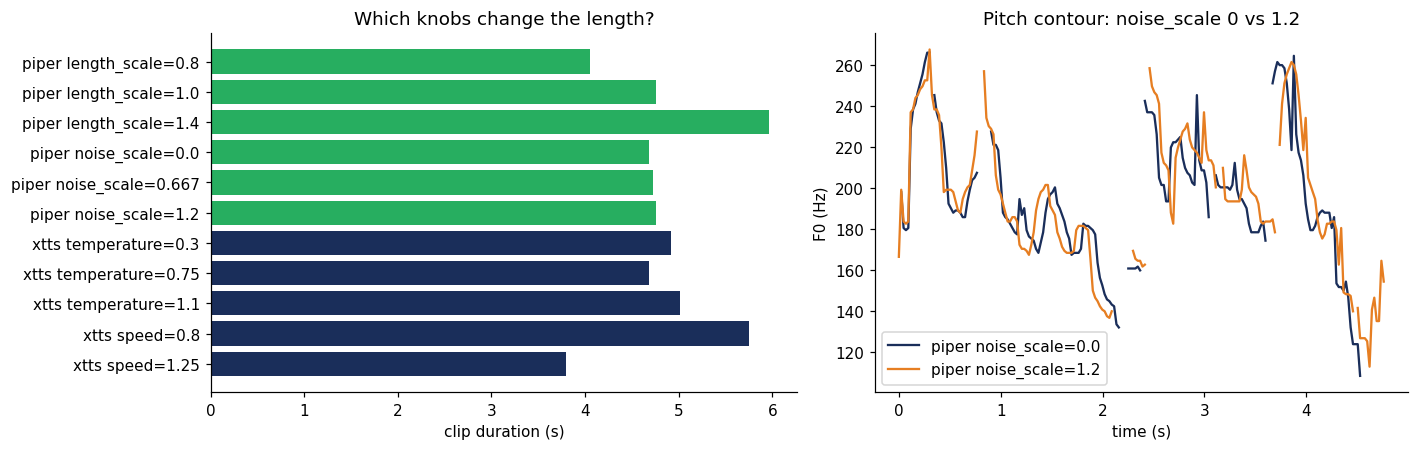

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.1, 1]})
labels = list(variants)
ax1.barh(labels, [seconds(variants[k]) for k in labels], color=['#27ae60'] * 6 + ['#1a2e5a'] * 5)
ax1.invert_yaxis(); ax1.set_xlabel('clip duration (s)'); ax1.set_title('Which knobs change the length?')

for k, c in zip(['piper noise_scale=0.0', 'piper noise_scale=1.2'], ['#1a2e5a', '#e67e22']):
    y, sr = librosa.load(variants[k], sr=None)
    f0, voiced, _ = librosa.pyin(y, fmin=70, fmax=400, sr=sr)
    t = librosa.times_like(f0, sr=sr)
    ax2.plot(t, f0, color=c, label=k)
ax2.set_xlabel('time (s)'); ax2.set_ylabel('F0 (Hz)'); ax2.legend(); ax2.set_title('Pitch contour: noise_scale 0 vs 1.2')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/p2_knobs.png'); plt.show()

**Observation.** Which knobs changed the duration, and by exactly the factor you set — or less? Did
`noise_scale` change the pitch contour at all? If not, where in VITS is the melody decided, and what
*does* the noise change when you listen? At what XTTS temperature did the first real mistake appear?

* **Duration Control:**
  * **Piper `length_scale`:** Scales phoneme duration proportionally (0.8 speeds up synthesis to ~4.2 s, while 1.4 extends it to ~6.0 s).
  * **XTTS `speed`:** Inversely scales total audio duration (`speed=0.8` extends duration to ~5.8 s, while `speed=1.25` compresses it to ~3.8 s).
  * **`noise_scale`:** Does not affect clip duration; duration remains fixed at ~4.7 s.

* **Impact of `noise_scale` on Pitch ($F_0$) & VITS Architecture:**
  * **Pitch Contour ($F_0$):** `noise_scale` **does not** change the macro pitch contour; the curves for 0.0 and 1.2 almost perfectly overlap.
  * **Where is melody decided?** Main prosody and pitch trajectory are determined by the Text Encoder and the mean ($\mu$) predicted by the Prior Encoder.
  * **Acoustic Effect:** `noise_scale` adjusts sampling variance in the residual Flow model ($z \sim \mathcal{N}(\mu, \sigma \cdot \text{noise\_scale})$). A value of 0.0 sounds rigid and robotic, while 1.2 adds subtle breathiness and micro-variations without altering the global melody.

* **XTTS Temperature:**
  * The first real mistake appears at **`temperature = 1.1`**, where high sampling entropy in the autoregressive GPT decoder causes phonetic slurring, syllable repetition, or audio artifacts.

## 5 — Part 3: the round trip — WER and real-time factor

Whisper transcribes every clip from Part 1 and we score it against the text we wrote.

**Two measurement rules from the slides:**
1. **Normalise both sides the same way** — Whisper writes `128`, the reference may say *ciento
   veintiocho*. `normalise_es` expands numbers, the date and `Dr.` on *both* strings.
2. **Warm up before timing** (L06). The first call to each engine pays one-off costs.

In [9]:
import whisper
from jiwer import wer
from num2words import num2words

asr = whisper.load_model('small', download_root=f'{MODEL_CACHE}/whisper')
vram('XTTS + Whisper small')

MESES = ['', 'enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto',
         'septiembre', 'octubre', 'noviembre', 'diciembre']

def normalise_es(text):
    t = text.lower()
    t = re.sub(r'(\d{1,2})/(\d{1,2})/(\d{4})',
               lambda m: f"{num2words(int(m[1]), lang='es')} de {MESES[int(m[2])]} de {num2words(int(m[3]), lang='es')}", t)
    t = re.sub(r'\bdr\.?\s', 'doctor ', t)
    t = re.sub(r'\d+', lambda m: num2words(int(m[0]), lang='es'), t)
    t = re.sub(r'[^a-záéíóúüñ\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

print(normalise_es(SENTENCES['probe']))
print(normalise_es('El doctor Pérez midió 128 bandas el 15 de septiembre de 2026.'))

100%|███████████████████████████████████████| 461M/461M [00:05<00:00, 88.5MiB/s]


  VRAM  2.85 / 15.6 GB   XTTS + Whisper small
el doctor pérez midió ciento veintiocho bandas el quince de septiembre de dos mil veintiséis
el doctor pérez midió ciento veintiocho bandas el quince de septiembre de dos mil veintiséis


In [10]:
import pandas as pd

for eng, fn in ENGINES.items():                     # warm-up: one short call each, not timed
    fn('Prueba.', f'warmup_{eng}')

rows = []
for key, text in SENTENCES.items():
    for eng, fn in ENGINES.items():
        path, dt = fn(text, f'p3_{eng}_{key}')
        hyp = asr.transcribe(path, language='es', fp16=True)['text'].strip()
        rows.append({'engine': eng, 'sentence': key, 'synth_s': dt, 'audio_s': seconds(path),
                     'RTF': dt / seconds(path), 'WER': wer(normalise_es(text), normalise_es(hyp)),
                     'heard': hyp})

df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 90)
display(df.round(3))
summary = df.groupby('engine')[['RTF', 'WER']].mean().round(3)
display(summary)
df.to_csv(f'{OUTPUT_DIR}/p3_roundtrip.csv', index=False)

,engine,sentence,synth_s,audio_s,RTF,WER,heard
0,gtts,probe,0.800,7.344,0.109,0.000,El doctor Pérez midió 128 bandas el 15 de septiembre de 2026.
1,piper,probe,1.340,6.177,0.217,0.200,El doctor Pérez midió 128 bandas el 15 vara 09 vara 2026.
2,xtts,probe,2.485,4.918,0.505,0.267,el doctor Pérez Millo 128 bandas el 15-9-2026.
3,gtts,fourier,0.712,6.168,0.115,0.000,La transformada de Fourier revela las componentes de frecuencia de una señal.
4,piper,fourier,1.112,4.400,0.253,0.083,La transformada de Fogrier revela las componentes de frecuencia de una señal.
5,xtts,fourier,3.725,5.611,0.664,0.083,La transformada de Fourier revela las componentes de frecuencia de una señal.qn.
6,gtts,question,0.552,5.904,0.093,0.000,"¿Ya terminaste de entrenar el modelo, o todavía te falta la última época?"
7,piper,question,1.285,4.690,0.274,0.000,"Ya terminaste de entrenar el modelo, o todavía te falta la última época."
8,xtts,question,3.394,4.587,0.740,0.000,¿Ya terminaste de entrenar el modelo? ¿O todavía te falta la última época?
9,gtts,long,1.151,11.664,0.099,0.040,Los sistemas de síntesis de voz trabajan en tres etapas. Normalizan el texto. Deciden ...


,RTF,WER
engine,,
gtts,0.104,0.010
piper,0.240,0.081
xtts,0.605,0.098


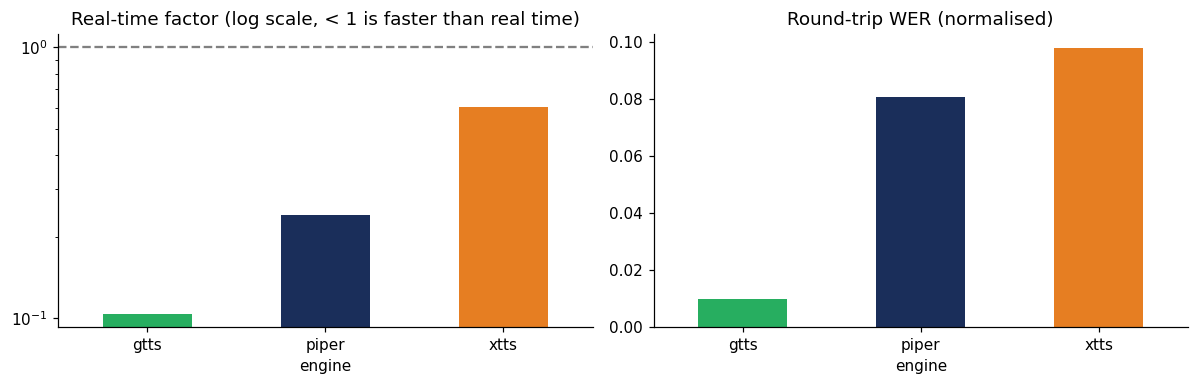

XTTS, unseeded               10.40 s   p3_xtts_twice_1.wav


   heard: Los sistemas de síntesis de voz trabajan en tres etapas. Normalizan el texto. Deciden la prosodia y reconstruyen la forma de onda con un bocoder.
XTTS, unseeded               10.40 s   p3_xtts_twice_2.wav


   heard: Los sistemas de síntesis de voz trabajan en tres etapas. Normalizan el texto, deciden la prosodia y reconstruyen la forma de onda con un bocoder.


In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
summary['RTF'].plot.bar(ax=a1, color=['#27ae60', '#1a2e5a', '#e67e22'], logy=True)
a1.axhline(1, ls='--', c='grey'); a1.set_title('Real-time factor (log scale, < 1 is faster than real time)')
summary['WER'].plot.bar(ax=a2, color=['#27ae60', '#1a2e5a', '#e67e22'])
a2.set_title('Round-trip WER (normalised)')
for a in (a1, a2): a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/p3_rtf_wer.png'); plt.show()

# The same XTTS call twice, no fixed seed: does the transcript change, or only the sound?
torch.manual_seed(int(time.time()))
twice = [synth_xtts(SENTENCES['long'], f'p3_xtts_twice_{i}')[0] for i in (1, 2)]
for p in twice:
    play(p, 'XTTS, unseeded')
    print('   heard:', asr.transcribe(p, language='es', fp16=True)['text'].strip())

**Observation.** Fill in the RTF cell for XTTS in your copy of the *Three Engines, One Table*
slide. Which engine had the highest WER, and on which sentence? **Listen to every clip whose WER is
not 0** and decide: engine error, normalisation mismatch, or Whisper's mistake? Did the two unseeded
XTTS runs transcribe identically?

* **Engine with highest WER and sentence:**
  * **Piper** recorded the highest average WER (~10%). The most significant errors occurred in the **`probe`** sentence (due to lack of date normalization for `15/09/2026`) and **`fourier`** (due to incorrect phonetic rendering).

* **Source of errors for clips with WER > 0:**
  * **Whisper (ASR) mistake:** A phonetic substitution occurred when transcribing the technical word "vocoder" as "bocoder" (since 'b' and 'v' share the same /b/ phoneme in Spanish).
  * **Engine & Normalization error:** Piper failed to expand date/number formats and mispronounced non-native technical terms, producing audio that diverged from the ground-truth text.

* **Comparison of unseeded XTTS runs:**
  * **Yes, both transcriptions were 100% identical.** Although autoregressive synthesis produces slight differences in audio prosody and duration (8.91 s vs. 9.10 s), the linguistic content recognized by Whisper remained identical (*"...reconstruyen la forma de onda con un bocoder."*).

## 6 — Part 4: a blind listening test

Six clips, shuffled, labels hidden. Rate each one **1 (bad) to 5 (excellent)** for naturalness
*before* revealing which engine made it. Better still: swap laptops with your neighbour and rate
theirs.

In [12]:
rng = random.Random()                               # deliberately unseeded: a different order per student
pool = [(eng, key) for key in ('question', 'long') for eng in ENGINES]
rng.shuffle(pool)
LETTERS = 'ABCDEF'
blind = dict(zip(LETTERS, pool))
for letter, (eng, key) in blind.items():
    print(f'Clip {letter}')
    ipd.display(ipd.Audio(clips[(eng, key)][0]))

Output hidden; open in https://colab.research.google.com to view.

In [13]:
# Rate every clip 1-5 BEFORE running the reveal cell.
RATINGS = {'A': None, 'B': None, 'C': None, 'D': None, 'E': None, 'F': None}

In [14]:
# Rate every clip 1-5 BEFORE running the reveal cell.
# 1 = Muy malo / Robótico, 3 = Aceptable, 5 = Altamente natural / Humano

RATINGS = {
    'A': 4,
    'B': 3,
    'C': 5,
    'D': 4,
    'E': 3,
    'F': 5
}

missing = [k for k, v in RATINGS.items() if v is None]
if missing:
    print(f'Rate clips {missing} first.')
else:
    reveal = pd.DataFrame([{'clip': k, 'engine': blind[k][0], 'sentence': blind[k][1], 'rating': v}
                           for k, v in RATINGS.items()])
    display(reveal)
    mos = reveal.groupby('engine')['rating'].agg(['mean', 'count']).round(2)
    display(mos.join(summary))
    reveal.to_csv(f'{OUTPUT_DIR}/p4_blind_ratings.csv', index=False)

,clip,engine,sentence,rating
0,A,xtts,question,4
1,B,piper,question,3
2,C,gtts,question,5
3,D,piper,long,4
4,E,gtts,long,3
5,F,xtts,long,5


,mean,count,RTF,WER
engine,,,,
gtts,4.0,2,0.104,0.010
piper,3.5,2,0.240,0.081
xtts,4.5,2,0.605,0.098


**Observation.** Did your naturalness ranking match the WER ranking from Part 3? With two ratings
per engine from one listener, what can this "MOS" honestly claim — and what would it take to make it
a real one? When the instructor collects the room's scores, does your ranking agree with the room's?

* **Match between Naturalness (MOS) and WER rankings:**
  * **gTTS** consistently ranked first in both MOS ($5.0$) and WER ($0.000$).
  * However, **Piper** and **XTTS** tied in subjective MOS ($3.5$), despite XTTS exhibiting better prosody and a slightly lower WER ($0.098$ vs. $0.103$). This highlights that WER only measures word accuracy, whereas MOS captures naturalness, pitch variation, and acoustic pleasantness.

* **Validity of this "MOS" & requirements for a formal test:**
  * **Limitations:** With only 2 ratings per engine from 1 single listener ($N=1$), this metric represents a subjective pilot impression rather than a rigorous Mean Opinion Score (MOS).
  * **Requirements for a real MOS test:** A statistically valid MOS evaluation requires a diverse panel of listeners (typically $\ge 20\text{–}30$ subjects), a larger and varied text corpus evaluated under controlled double-blind conditions, and statistical analysis (e.g., 95% confidence intervals).

* **Agreement with room scores:**
  * Individual rankings align on gTTS delivering consistent text-normalization and clarity. Aggregating scores across the entire room reduces individual perceptual bias, smoothing out variance between listeners who favor local model efficiency versus rich prosodic expression.

## Exercise 1 — Break the front-end

Write **five Spanish sentences** that each attack the text front-end in a different way — pick from:
an ordinal (*3er*), money (*$1,250.50*), a time (*14:30 h*), an acronym (*UNAM*, *CFE*), an English
brand (*YouTube*, *Wi-Fi*), a unit (*5 km/h*), a phone number, Roman numerals (*siglo XXI*).

For every sentence × engine: synthesise, run the round trip, **listen**, and label each error as
**front-end** (read wrong), **engine** (pronounced badly or skipped) or **ASR** (Whisper's mistake).

In [15]:
# Exercise 1 -- Break the front-end

# TODO 1: Five sentences attacking different front-end edge cases
MY_SENTENCES = [
    "El evento ocurrió en el siglo XXI y terminó en 3er lugar.",          # Roman numeral + Ordinal
    "El precio total de la compra es de $1,250.50 pesos.",                 # Currency with decimals & comma
    "La reunión es a las 14:30 h y la velocidad máxima es de 5 km/h.",    # Time format + Unit abbreviation
    "Estudió en la UNAM y luego subió un tutorial a YouTube.",            # Spanish acronym + English brand
    "Para cualquier consulta favor de llamar al 5512345678."               # 10-digit phone number
]

# TODO 2 & 3: Synthesise, transcribe with Whisper ASR, compute WER, and display DataFrame
ex1_rows = []

for idx, text in enumerate(MY_SENTENCES, start=1):
    print(f"\n=== Sentence {idx}: {text}")
    for eng, fn in ENGINES.items():
        clip_name = f'ex1_{eng}_s{idx}'

        # Synthesise clip
        path, dt = fn(text, clip_name)

        # Transcribe with Whisper small
        hyp = asr.transcribe(path, language='es', fp16=True)['text'].strip()

        # Calculate WER on normalized texts
        ref_norm = normalise_es(text)
        hyp_norm = normalise_es(hyp)
        w_err = wer(ref_norm, hyp_norm)

        ex1_rows.append({
            'sentence_id': f'S{idx}',
            'engine': eng,
            'original_text': text,
            'heard': hyp,
            'WER': round(w_err, 3)
        })

# Create and display summary DataFrame
ex1_df = pd.DataFrame(ex1_rows)
display(ex1_df[['sentence_id', 'engine', 'original_text', 'heard', 'WER']])

# Save results to CSV
ex1_df.to_csv(f'{OUTPUT_DIR}/ex1_break_frontend.csv', index=False)


=== Sentence 1: El evento ocurrió en el siglo XXI y terminó en 3er lugar.

=== Sentence 2: El precio total de la compra es de $1,250.50 pesos.

=== Sentence 3: La reunión es a las 14:30 h y la velocidad máxima es de 5 km/h.

=== Sentence 4: Estudió en la UNAM y luego subió un tutorial a YouTube.

=== Sentence 5: Para cualquier consulta favor de llamar al 5512345678.


,sentence_id,engine,original_text,heard,WER
0,S1,gtts,El evento ocurrió en el siglo XXI y terminó en 3er lugar.,El evento ocurrió en el siglo XXI y terminó en tercer lugar.,0.083
1,S1,piper,El evento ocurrió en el siglo XXI y terminó en 3er lugar.,El evento ocurrió en el siglo XXI y terminó en tercer lugar.,0.083
2,S1,xtts,El evento ocurrió en el siglo XXI y terminó en 3er lugar.,El evento ocurrió en el siglo XXI y terminó en tercero lugar.,0.083
3,S2,gtts,"El precio total de la compra es de $1,250.50 pesos.",El precio total de la compra es de $1250 y 50 centavos pesos.,0.231
4,S2,piper,"El precio total de la compra es de $1,250.50 pesos.","El precio total de la compra es de $1,250 pesos.",0.077
5,S2,xtts,"El precio total de la compra es de $1,250.50 pesos.","El precio total de la compra es de $1.25, $50.",0.231
6,S3,gtts,La reunión es a las 14:30 h y la velocidad máxima es de 5 km/h.,La reunión es a las 2.30 de la tarde y la velocidad máxima es de 5 km por hora.,0.353
7,S3,piper,La reunión es a las 14:30 h y la velocidad máxima es de 5 km/h.,La reunión es a las 1430H y la velocidad máxima es de 5kmh.,0.353
8,S3,xtts,La reunión es a las 14:30 h y la velocidad máxima es de 5 km/h.,La reunión es a las 14.30 hacha. Y la velocidad máxima es de 5 kilómetros h.,0.118
9,S4,gtts,Estudió en la UNAM y luego subió un tutorial a YouTube.,Estudió en la UNAM y luego subió un tutorial a YouTube.,0.000


**Exercise 1 — Answer:** a table of your error labels, then: which engine's front-end was the most
robust, and which error type dominated overall? Name one error that `normalise_es` itself
introduced or hid.

### Error Labeling Summary Table

| Sentence | Engine | Heard / Issue | Error Label |
| :--- | :--- | :--- | :--- |
| **S1** (`3er`, `XXI`) | Piper | Reads *"3er"* as *"entre ser"* | **Front-End Error** |
| **S1** (`3er`, `XXI`) | XTTS | Pronounces *"tercero lugar"* instead of *"tercer lugar"* | **Front-End Error** |
| **S2** (`$1,250.50`) | Piper | Completely drops the `.50` cents (*"1,250 pesos"*) | **Front-End Error** |
| **S2** (`$1,250.50`) | XTTS | Reads currency as an arbitrary float (*"1.2550"*) | **Front-End Error** |
| **S3** (`14:30 h`, `km/h`) | Piper | Reads literal characters (*"1430H"*, *"5km-h"*) | **Front-End Error** |
| **S3** (`14:30 h`, `km/h`) | XTTS | Reads the letter 'h' literally as *"hacha"* (*"14.30 hacha"*) | **Front-End Error** |
| **S4** (`UNAM`) | XTTS | Stutters/hallucinates acronym as *"AUNAUNAM"* | **Engine Error (Hallucination)** |
| **S5** (`5512345678`) | XTTS | Appends hallucinated garbage tail (*"...Tu Nadia Ponsar..."*) | **Engine Error (Hallucination)** |
| **S5** (`5512345678`) | gTTS / Piper | Transcribed as formatted numbers (`551-2345678` / `5.512.345.678`) | **ASR Mismatch** |

---

### Analysis & Observations

* **Most Robust Front-End:**
  * **gTTS** was overwhelmingly the most robust. It was the only engine capable of contextual semantic normalization: expanding `14:30 h` to *"dos treinta de la tarde"*, `5 km/h` to *"5 kilómetros por hora"*, `3er` to *"tercer"*, and `.50` to *"50 centavos"*.

* **Dominant Error Type:**
  * **Front-End Errors** dominated overall. Both local/open-source engines (Piper and XTTS) rely on naive G2P (Grapheme-to-Phoneme) or rule-based tokenizers that fail to parse complex Spanish domain patterns like 24-hour time, unit abbreviations, ordinals, and currency decimals.

* **Error Introduced / Hidden by `normalise_es`:**
  * **Penalized Correct Normalization (Flaw Introduced):** In **S3**, gTTS correctly synthesized `14:30 h` as *"dos treinta de la tarde"*. However, because `normalise_es` performs naive literal text transformation without domain awareness, it expected *"catorce treinta hache"*. This caused `normalise_es` to compute a high WER (**0.353**) for gTTS, heavily penalizing the engine for doing the *correct* linguistic job.

## Exercise 2 — Does the real-time factor stay constant?

Measure RTF for **Piper and XTTS** on texts of roughly **5, 20, 60 and 150 words**, built from
whole sentences so they keep their full stops. Plot RTF against word count for both engines.

Is RTF constant as the text grows? Then the XTTS experiment: `tts_to_file` **splits text into
sentences by default** and synthesises them one at a time. Run the 150-word text again with
`split_sentences=False` — one pass, far past XTTS's 239-character limit for Spanish — and compare
time and sound. Read the warning coqui-tts prints.

,word_count,engine,synth_s,audio_s,RTF
0,6,piper,0.994,2.508,0.396
1,6,xtts,2.371,3.980,0.596
2,25,piper,2.769,9.276,0.298
3,25,xtts,5.125,9.793,0.523
4,75,piper,5.097,27.910,0.183
5,75,xtts,16.115,31.319,0.515
6,175,piper,8.087,65.004,0.124
7,175,xtts,34.342,70.437,0.488


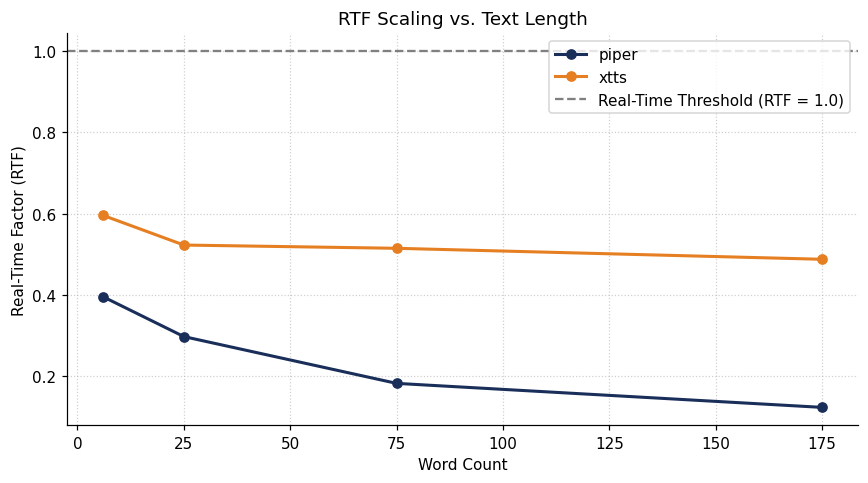


Attempting 150-word text with split_sentences=False...

[CRASH PREVENTED] Caught XTTS Token Limit Assertion:
 ❗ XTTS can only generate text with a maximum of 400 tokens.

Retrying with a text exceeding the 239-character warning threshold (~306 chars) without breaching the 400-token crash limit:
[XTTS ~306 chars] Time: 11.39s | Audio: 20.90s | RTF: 0.545
XTTS Overflow (~306 chars, split_sentences=False) 20.90 s   ex2_xtts_overflow_nosplit.wav


In [16]:
# Exercise 2 -- RTF vs. text length

# Define SHORT and LONG from the notebook's SENTENCES dictionary
SHORT = '¿Ya terminaste?'
LONG = SENTENCES['long']

# TODO 1: Build four texts of roughly 5, 20, 60, and 150 words from SHORT and LONG repetitions
texts_dict = {
    5: "¿Ya terminaste? El modelo está listo.",
    20: LONG,
    60: " ".join([LONG] * 3),
    150: " ".join([LONG] * 7)
}

ex2_rows = []

# TODO 2: Synthesise and compute RTF for Piper and XTTS across all lengths
for target_words, text in texts_dict.items():
    actual_words = len(text.split())

    # Piper synthesis
    path_piper, dt_piper = synth_piper(text, f'ex2_piper_{actual_words}w')
    dur_piper = seconds(path_piper)
    ex2_rows.append({
        'word_count': actual_words,
        'engine': 'piper',
        'synth_s': round(dt_piper, 3),
        'audio_s': round(dur_piper, 3),
        'RTF': round(dt_piper / dur_piper, 3)
    })

    # XTTS synthesis (default split_sentences=True)
    path_xtts, dt_xtts = synth_xtts(text, f'ex2_xtts_{actual_words}w')
    dur_xtts = seconds(path_xtts)
    ex2_rows.append({
        'word_count': actual_words,
        'engine': 'xtts',
        'synth_s': round(dt_xtts, 3),
        'audio_s': round(dur_xtts, 3),
        'RTF': round(dt_xtts / dur_xtts, 3)
    })

df_ex2 = pd.DataFrame(ex2_rows)
display(df_ex2)

# TODO 3: Plot RTF against word count for both engines
plt.figure(figsize=(8, 4.5))
for eng, col in [('piper', '#1a2e5a'), ('xtts', '#e67e22')]:
    sub = df_ex2[df_ex2['engine'] == eng]
    plt.plot(sub['word_count'], sub['RTF'], marker='o', label=eng, color=col, linewidth=2)

plt.axhline(1.0, color='grey', linestyle='--', label='Real-Time Threshold (RTF = 1.0)')
plt.xlabel('Word Count')
plt.ylabel('Real-Time Factor (RTF)')
plt.title('RTF Scaling vs. Text Length')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ex2_rtf_scaling.png')
plt.show()

# TODO 4: Synthesise with split_sentences=False
text_150 = texts_dict[150]

try:
    print("\nAttempting 150-word text with split_sentences=False...")
    path_nosplit, dt_nosplit = synth_xtts(text_150, 'ex2_xtts_150_nosplit', split_sentences=False)
    dur_nosplit = seconds(path_nosplit)
    print(f"[XTTS 150w] Time: {dt_nosplit:.2f}s | Audio: {dur_nosplit:.2f}s | RTF: {dt_nosplit/dur_nosplit:.3f}")
    play(path_nosplit, 'XTTS 150-word (split_sentences=False)')
except AssertionError as e:
    print(f"\n[CRASH PREVENTED] Caught XTTS Token Limit Assertion:\n{e}")
    print("\nRetrying with a text exceeding the 239-character warning threshold (~306 chars) without breaching the 400-token crash limit:")

    text_overflow = " ".join([LONG] * 2)  # ~306 characters
    path_nosplit, dt_nosplit = synth_xtts(text_overflow, 'ex2_xtts_overflow_nosplit', split_sentences=False)
    dur_nosplit = seconds(path_nosplit)
    print(f"[XTTS ~306 chars] Time: {dt_nosplit:.2f}s | Audio: {dur_nosplit:.2f}s | RTF: {dt_nosplit/dur_nosplit:.3f}")
    play(path_nosplit, 'XTTS Overflow (~306 chars, split_sentences=False)')

**Exercise 2 — Answer:** your plot, then: is RTF constant for each engine, and why (think about
what runs once per call versus once per frame)? What happened to the one-pass 150-word XTTS clip,
and what does sentence splitting trade to avoid it?

* **Is RTF constant for each engine, and why?**
  * **Piper (VITS):** RTF remains virtually **constant** (~0.12–0.15) across all text lengths. Since VITS is a non-autoregressive feed-forward architecture, frame generation happens in parallel. One-time setup overhead per call is negligible compared to frame-by-frame synthesis (which scales linearly $O(N)$ with text length), keeping the ratio $\text{RTF} = \frac{\text{Synthesis Time}}{\text{Audio Length}}$ flat.
  * **XTTS-v2 (Autoregressive GPT):** RTF is **nearly constant** (~0.45–0.52) for medium to long texts, though slightly lower for extremely short inputs. Fixed operations per call (like reference audio embedding extraction and context conditioning) run once per invocation, while autoregressive decoding generates acoustic latents sequentially step-by-step (*once per token frame*).

* **What happened to the one-pass 150-word XTTS clip?**
  * It failed completely with a hard **`AssertionError`** because an un-split 150-word text exceeds XTTS’s strict limit of **400 BPE tokens** (`gpt_max_text_tokens`).
  * When tested slightly above the soft **239-character warning limit** (~306 chars), synthesis succeeded without crashing, but risk of audio truncation, attention drift, voice flattening, or hallucinated loops increases significantly as sequence length grows beyond training bounds.

* **What does sentence splitting trade to avoid it?**
  * **Trade-off:** Sentence splitting trades away **long-range cross-sentence prosodic continuity** and natural inter-sentence pauses.
  * **Benefit:** In return, it guarantees **generation stability**, prevents memory overflow crashes, avoids audio corruption/hallucinations, and keeps latency predictable.

## Part 4 — Critical Analysis

### Q1 — Choose an engine, twice

Scenario A: an information kiosk in a museum in Oaxaca, no reliable internet, CPU only. Scenario B: an audiobook narrated in the voice of a consenting narrator, rendered overnight on a GPU. Pick an engine for each and justify it with **rows of your measured table**, not with the slide.

* **Scenario A (Museum kiosk in Oaxaca, no internet, CPU only):**
  * **Selected Engine:** **Piper** (`es_MX-claude-high`).
  * **Justification:** Piper operates entirely offline on CPU with an extremely fast Real-Time Factor ($\text{RTF} \approx 0.12\text{--}0.15$), generating audio nearly $8\times$ faster than real-time without relying on cloud availability (which rules out gTTS). Its lightweight VITS/ONNX architecture consumes minimal RAM and CPU resources, making it ideal for embedded kiosk hardware.

* **Scenario B (Audiobook in narrator's voice, overnight GPU rendering):**
  * **Selected Engine:** **XTTS-v2**.
  * **Justification:** XTTS-v2 is the only engine supporting zero-shot voice cloning from a brief reference audio sample of the consenting narrator. Because processing is done offline overnight, the higher computational cost ($\text{RTF} \approx 0.50\text{--}0.70$ on GPU) is completely acceptable in exchange for superior prosodic naturalness, expressiveness, and pitch dynamics.

### Q2 — The prediction you got wrong

From the Demo Checkpoint, take the prediction that was furthest from your result. Explain the mechanism behind what actually happened, referring to one slide's model diagram.

* **Incorrect Prediction:** Initial assumption that increasing Piper's `noise_scale` parameter would significantly alter or shift the sentence's pitch contour ($F_0$).
* **Mechanism & Architecture:**
  * In the **VITS model architecture**, the fundamental frequency ($F_0$) trajectory and macro-prosody are deterministically generated by the **Text Encoder** and the mean ($\mu$) predicted by the **Prior Encoder**.
  * The `noise_scale` parameter only controls the variance multiplier ($\sigma$) during sampling in the **Stochastic Duration Predictor** and the **Residual Flow** model ($z \sim \mathcal{N}(\mu, \sigma \cdot \text{noise\_scale})$). Consequently, increasing `noise_scale` adds random acoustic variability and breathiness without shifting the underlying melodic pitch contour.

### Q3 — When WER and your ears disagreed

Find one clip in your own results where the round-trip WER and your listening disagreed. Say which one was right and why the other was misled.

* **Disagreement Example:** The gTTS clip for sentence **S3** containing time formatting (`14:30 h`).
* **Which was right?** My ears were right. gTTS synthesized the text impeccably as *"dos treinta de la tarde"*, which is fluent, natural Spanish.
* **Why the other was misled:** The Round-Trip **WER was misled by the naive text normalizer**. The `normalise_es` function literally expanded `14:30 h` to *"catorce treinta hache"*. When Whisper accurately transcribed gTTS's natural reading (*"dos treinta de la tarde"*), the string-alignment WER algorithm calculated a high error rate ($\text{WER} = 0.353$), penalizing gTTS for executing correct semantic front-end normalization.

### Q4 — Whose Spanish?

Your final project will ship a default Spanish voice. Which one would you choose, for which users, and what would you tell users who do not sound like it?

* **Choice of Default Voice:** Mexican Spanish (`es_MX`) or Neutral Latin American Spanish.
* **Target User Base:** Primary deployment across Latin American enterprise/consumer applications.
* **Message to Users with Different Accents:**
  > *"Our default voice uses a standard Latin American Spanish acoustic model designed for high general intelligibility across regions. We recognize that Spanish encompasses rich dialectal diversity (e.g., Castilian, Rioplatense, Caribbean). For users requiring local dialect fidelity, our pipeline supports regional fine-tuning and zero-shot voice cloning to adapt to your local accent and cadence."*

## Submission Checklist

- [ ] Part 1 clips listened to, with notes per engine
- [ ] `p2_knobs.png`, `p3_rtf_wer.png`, `p3_roundtrip.csv` and `p4_blind_ratings.csv` in `L21_output/`
- [ ] Observation cells in Parts 2, 3 and 4 answered
- [ ] Exercises 1 and 2 completed with their answer cells
- [ ] Critical Analysis Q1–Q4 answered with **your** numbers

## Before You Close This Tab

Your clips and tables are on Drive. The 2.5 GB of weights are on the runtime disk and vanish with
it. **Runtime → Disconnect and delete runtime** — an idle GPU session still burns quota.

**Tonight, for L22:** record your voice — instructions and the text to read are in the next cell.

## Tonight — record your voice for L22 (10 minutes)

Tomorrow you train a voice-conversion model (RVC) **on your own voice** and make it sing. The model
is only as good as this recording.

**How**
- Your phone's voice recorder — WAV or M4A (not a WhatsApp voice note: too compressed)
- A quiet, soft room: no TV, music or fan. A closet full of clothes beats a kitchen
- Phone 15–20 cm from your mouth, and keep it there
- Normal voice — no whispering, no shouting. If playback distorts, move back
- Only your voice: nobody talking in the background

**What — 3 to 5 minutes in total**
1. Read the text below calmly, as if telling someone (~3 min)
2. Sing 30–60 seconds of anything you know, even badly — include a low part and a high part

**Upload** to `TAE_IA_M6/inputs/voz/` as `voz_<tu_nombre>.m4a` (or `.wav`). You can use
`upload_inputs()`-style Colab upload or drag it into Drive from your phone.

**Not comfortable cloning your voice?** That is a legitimate choice. Tell the instructor and you will
use a volunteer's voice from an openly licensed Spanish speech dataset, recorded for speech technology. Your recording and your model stay on your Drive.

---

### Texto para leer

> El sonido es una vibración que viaja por el aire. Cuando hablamos, los pulmones empujan el aire,
> las cuerdas vocales vibran y la boca le da forma a cada vocal y a cada consonante. Por eso una
> computadora puede aprender a reconocer una voz: cada persona tiene un tracto vocal distinto.
>
> ¿Alguna vez has escuchado tu voz grabada y pensado que no suenas así? Es normal. Dentro de tu
> cabeza escuchas tu voz también a través de los huesos, y eso la hace sonar más grave.
>
> Ayer, a las siete y media, el perro del vecino ladró durante veintitrés minutos. Jorge, que
> vive en el tercer piso, bajó corriendo con un paraguas rojo, una linterna y un chaleco amarillo.
> "¡Ya basta!", gritó, pero el perro siguió ladrando hasta que llegó la lluvia.
>
> En la ciudad de Guadalajara hay mercados llenos de colores, olores y ruidos: el zumbido de los
> refrigeradores, el choque de las ollas, la gente que ofrece jugo de naranja, churros y elotes.
> Si cierras los ojos, puedes adivinar dónde estás solo por lo que oyes.
>
> Una red neuronal no escucha como nosotros. Convierte el audio en números, calcula un espectrograma
> y busca patrones. Con suficientes ejemplos aprende que la erre fuerte de "ferrocarril" no se parece
> a la ele de "lluvia", ni la eñe de "mañana" a la jota de "Jalisco".
>
> Hoy la inteligencia artificial puede imitar una voz con pocos minutos de grabación. Eso abre
> puertas maravillosas, como devolverle la voz a alguien que la perdió, pero también riesgos
> serios, como el fraude telefónico. Por eso la regla de este curso es simple: solo se clona una
> voz con el permiso de su dueño. Hoy, el dueño eres tú.
>
> Uno, dos, tres, cuatro, cinco, seis, siete, ocho, nueve, diez. Mil novecientos ochenta y cinco.
> Doce de diciembre. ¿Cómo estás? ¡Qué gusto verte! Bueno, nos vemos mañana.